# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The Loan Risk Prediction Dataset](https://www.kaggle.com/datasets/algozee/credit-risk-and-loan-default-analysis-dataset)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

/kaggle/input/datasets/algozee/credit-risk-and-loan-default-analysis-dataset/loan_risk_prediction_dataset.csv


## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('loan_risk_prediction_dataset.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,Age,Income,LoanAmount,CreditScore,YearsExperience,Gender,Education,City,EmploymentType,LoanApproved
0,56,48353.0,31258.0,675.0,20,Female,High School,Houston,Unemployed,0
1,69,57462.0,23262.0,586.0,6,Male,High School,San Francisco,Self-Employed,0
2,46,44219.0,26530.0,781.0,26,Male,PhD,Houston,Self-Employed,1
3,32,56307.0,11531.0,549.0,11,Male,NaN,New York,Unemployed,0
4,60,37034.0,27871.0,500.0,19,Female,High School,Chicago,Unemployed,0


## last Five row

In [4]:
df.tail()

,Age,Income,LoanAmount,CreditScore,YearsExperience,Gender,Education,City,EmploymentType,LoanApproved
4995,24,36780.0,23383.0,NaN,23,Male,Masters,Houston,Salaried,0
4996,66,99146.0,9760.0,306.0,14,Male,PhD,New York,Unemployed,0
4997,26,58100.0,18230.0,311.0,10,Female,High School,San Francisco,Self-Employed,0
4998,53,58513.0,12373.0,813.0,23,Male,PhD,Houston,Salaried,1
4999,36,58928.0,23615.0,648.0,10,Male,NaN,New York,Self-Employed,1


## Shape of our dataset

In [5]:
df.shape

(5000, 10)

## List out all columns

In [6]:
df.columns

Index(['Age', 'Income', 'LoanAmount', 'CreditScore', 'YearsExperience',
       'Gender', 'Education', 'City', 'EmploymentType', 'LoanApproved'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

Age                  int64
Income             float64
LoanAmount         float64
CreditScore        float64
YearsExperience      int64
Gender              object
Education           object
City                object
EmploymentType      object
LoanApproved         int64
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age              5000 non-null   int64  
 1   Income           4804 non-null   float64
 2   LoanAmount       5000 non-null   float64
 3   CreditScore      4806 non-null   float64
 4   YearsExperience  5000 non-null   int64  
 5   Gender           5000 non-null   object 
 6   Education        4802 non-null   object 
 7   City             5000 non-null   object 
 8   EmploymentType   5000 non-null   object 
 9   LoanApproved     5000 non-null   int64  
dtypes: float64(3), int64(3), object(4)
memory usage: 390.8+ KB


## Check Null Value

In [9]:
df.isnull().sum()

Age                  0
Income             196
LoanAmount           0
CreditScore        194
YearsExperience      0
Gender               0
Education          198
City                 0
EmploymentType       0
LoanApproved         0
dtype: int64

## Fill numerical columns with Median

In [10]:
df['Income'].fillna(df['Income'].median(), inplace=True)
df['CreditScore'].fillna(df['CreditScore'].median(), inplace=True)

## Fill categorical column with Mode

In [11]:
df['Education'].fillna(df['Education'].mode()[0], inplace=True)

## Check missing values after handling

In [12]:
print("\nMissing values after handling:")
print(df.isnull().sum())


Missing values after handling:
Age                0
Income             0
LoanAmount         0
CreditScore        0
YearsExperience    0
Gender             0
Education          0
City               0
EmploymentType     0
LoanApproved       0
dtype: int64


## Check Dupicate Value

In [13]:
df.duplicated().sum()

np.int64(0)

## Summary

In [14]:
df.describe()

,Age,Income,LoanAmount,CreditScore,YearsExperience,LoanApproved
count,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,43.584600,49728.318200,19870.768600,575.63060,19.599000,0.230200
std,14.919094,14802.435406,8046.542413,157.40616,11.516837,0.421003
min,18.000000,-3731.000000,-10059.000000,300.00000,0.000000,0.000000
25%,31.000000,39990.250000,14455.250000,440.00000,10.000000,0.000000
50%,43.000000,49488.000000,19842.500000,579.00000,20.000000,0.000000
75%,56.000000,59447.000000,25326.750000,706.00000,29.000000,0.000000
max,69.000000,99146.000000,48353.000000,849.00000,39.000000,1.000000


# EDA

In [15]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

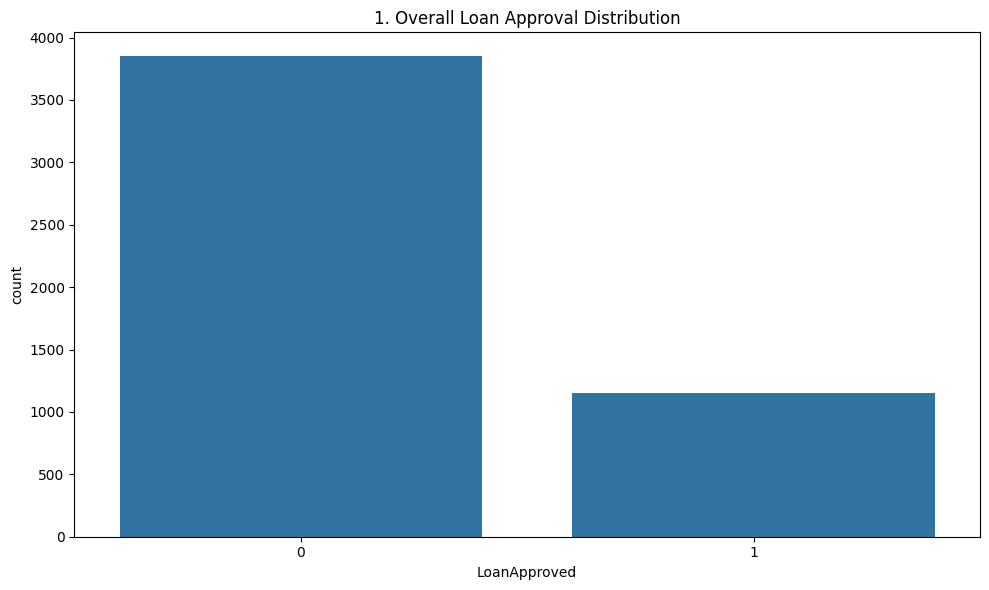

In [16]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='LoanApproved', data=df)
plt.title(f'{plot_no}. Overall Loan Approval Distribution')
show_fig()
plot_no += 1

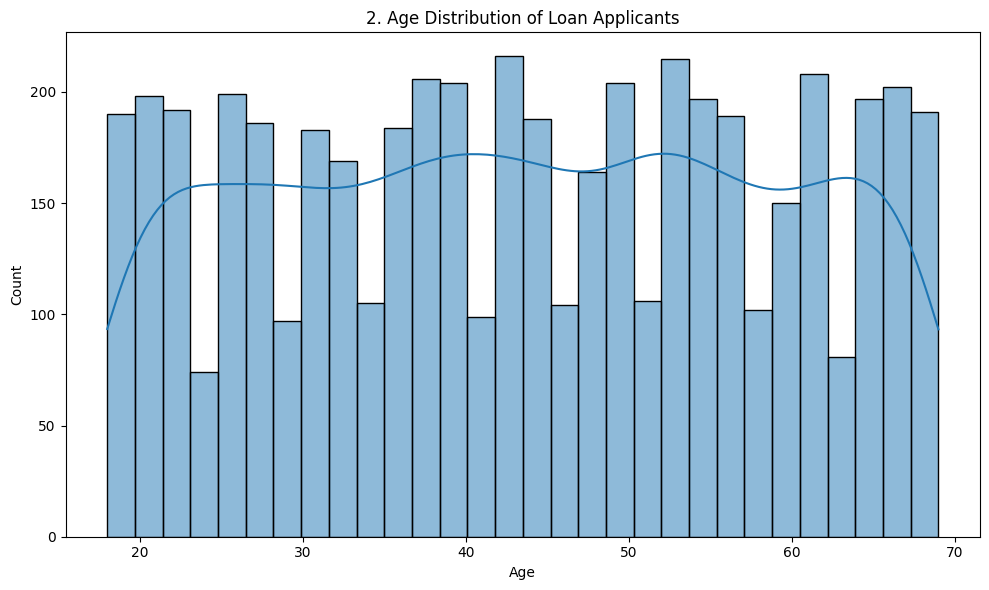

In [17]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['Age'], kde=True, bins=30)
plt.title(f'{plot_no}. Age Distribution of Loan Applicants')
show_fig()
plot_no += 1

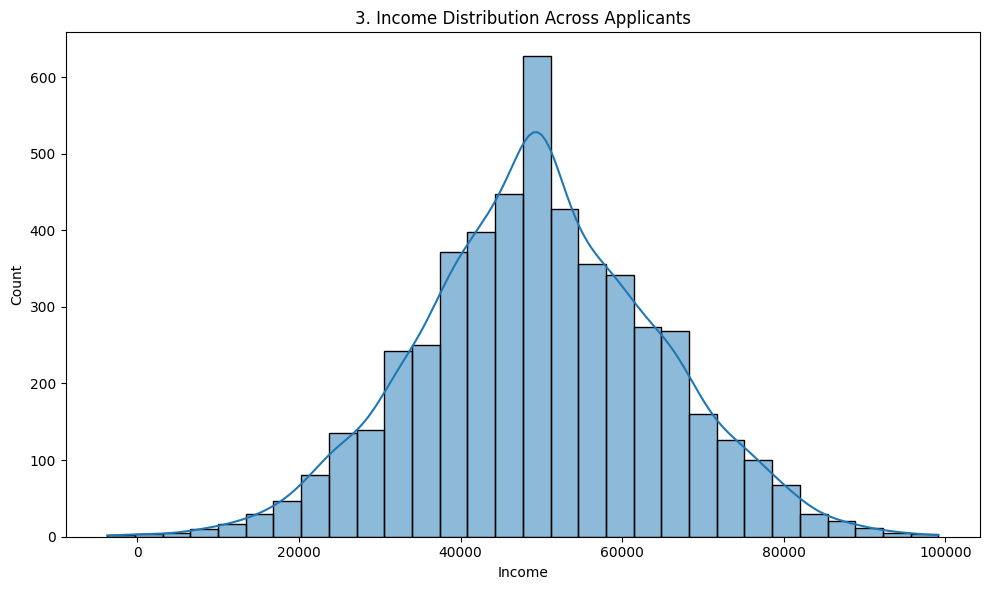

In [18]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['Income'], kde=True, bins=30)
plt.title(f'{plot_no}. Income Distribution Across Applicants')
show_fig()
plot_no += 1

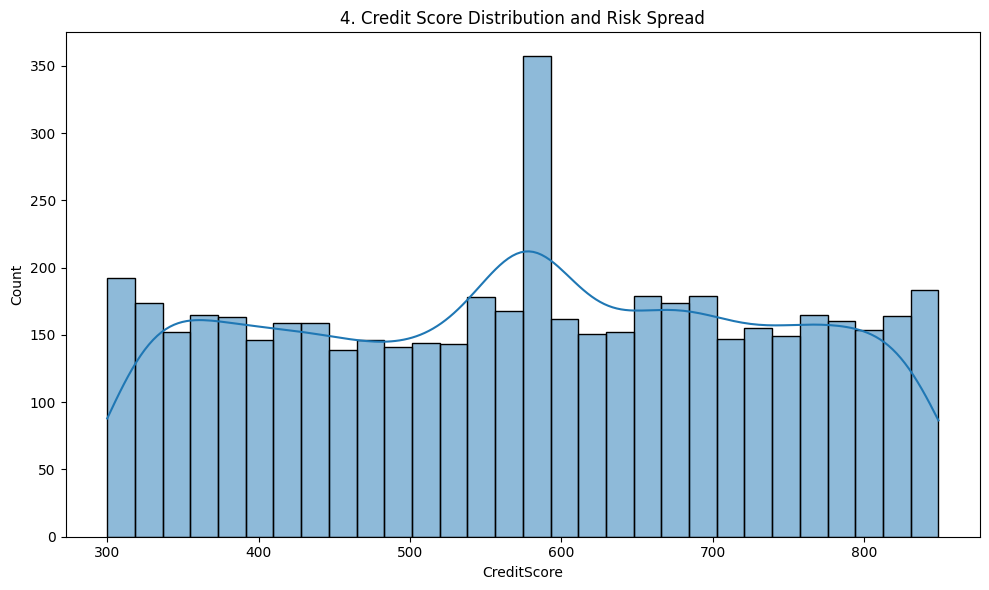

In [19]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['CreditScore'], kde=True, bins=30)
plt.title(f'{plot_no}. Credit Score Distribution and Risk Spread')
show_fig()
plot_no += 1

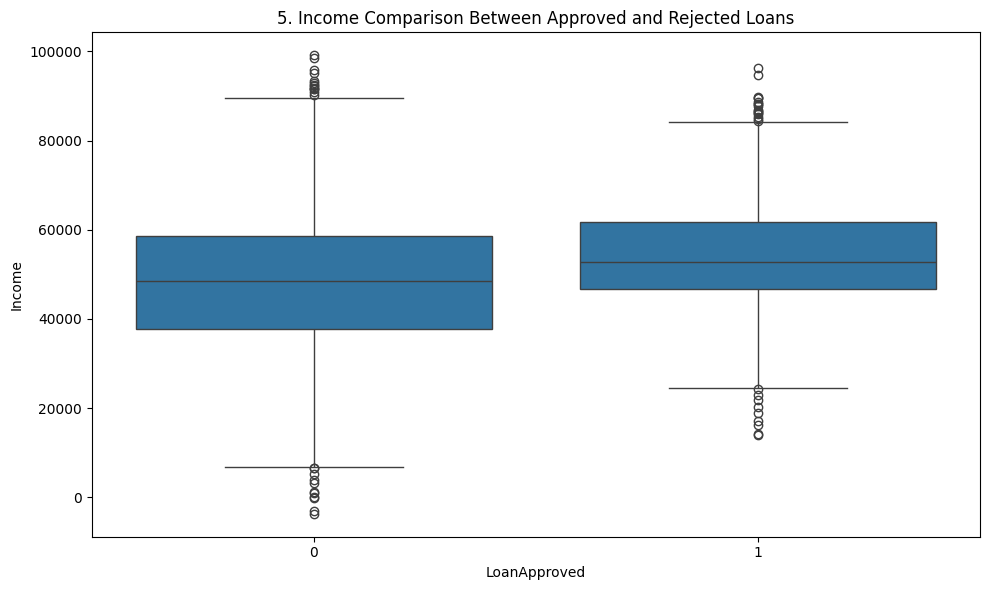

In [20]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='LoanApproved', y='Income', data=df)
plt.title(f'{plot_no}. Income Comparison Between Approved and Rejected Loans')
show_fig()
plot_no += 1

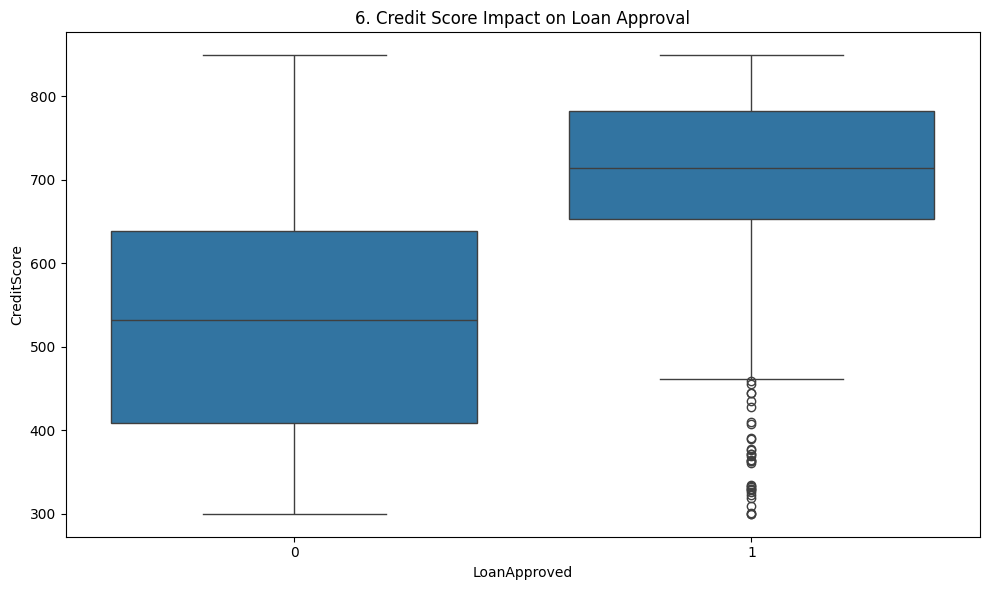

In [21]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='LoanApproved', y='CreditScore', data=df)
plt.title(f'{plot_no}. Credit Score Impact on Loan Approval')
show_fig()
plot_no += 1

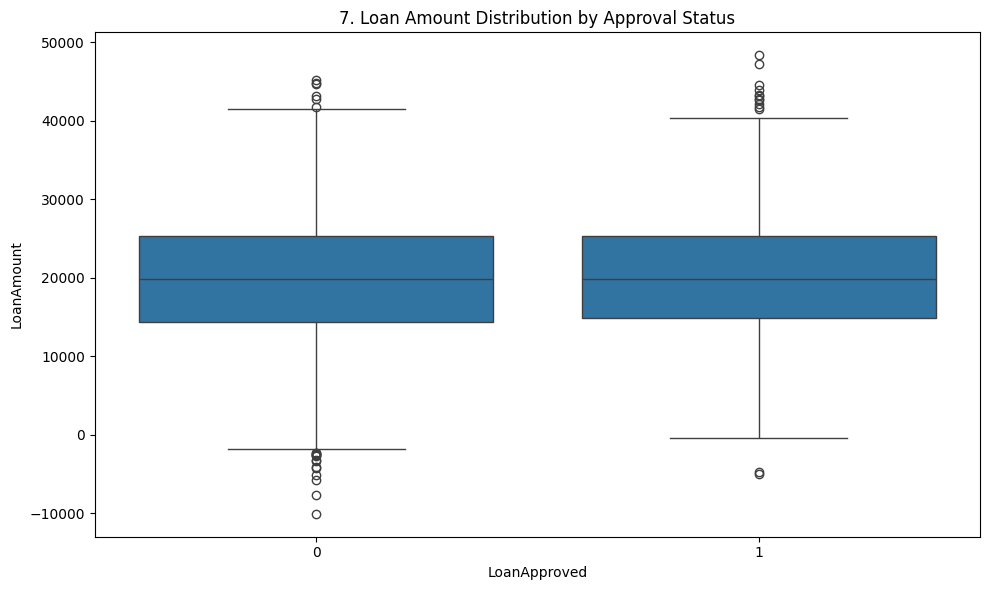

In [22]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='LoanApproved', y='LoanAmount', data=df)
plt.title(f'{plot_no}. Loan Amount Distribution by Approval Status')
show_fig()
plot_no += 1

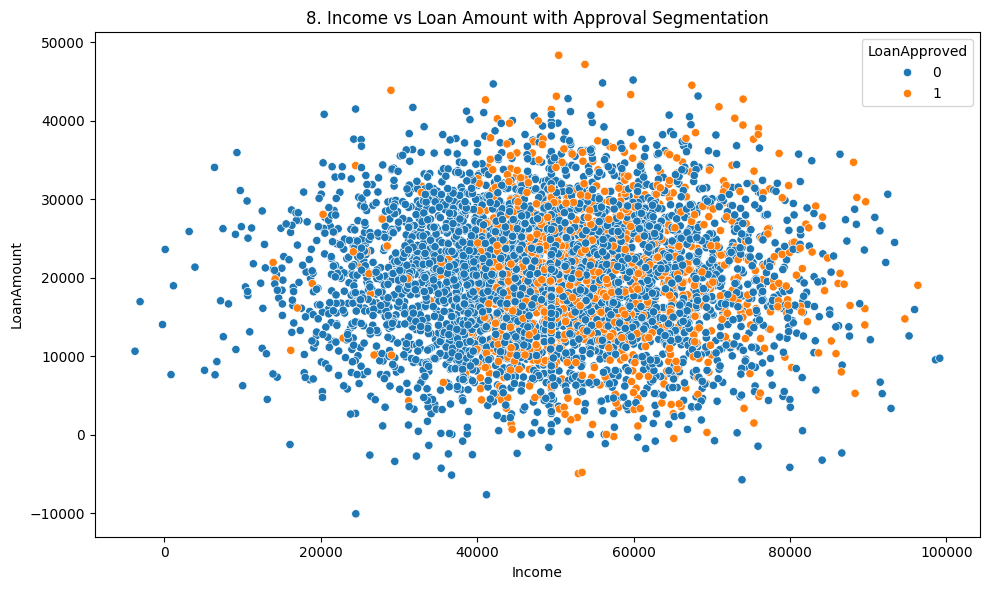

In [23]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='Income', y='LoanAmount', hue='LoanApproved', data=df)
plt.title(f'{plot_no}. Income vs Loan Amount with Approval Segmentation')
show_fig()
plot_no += 1

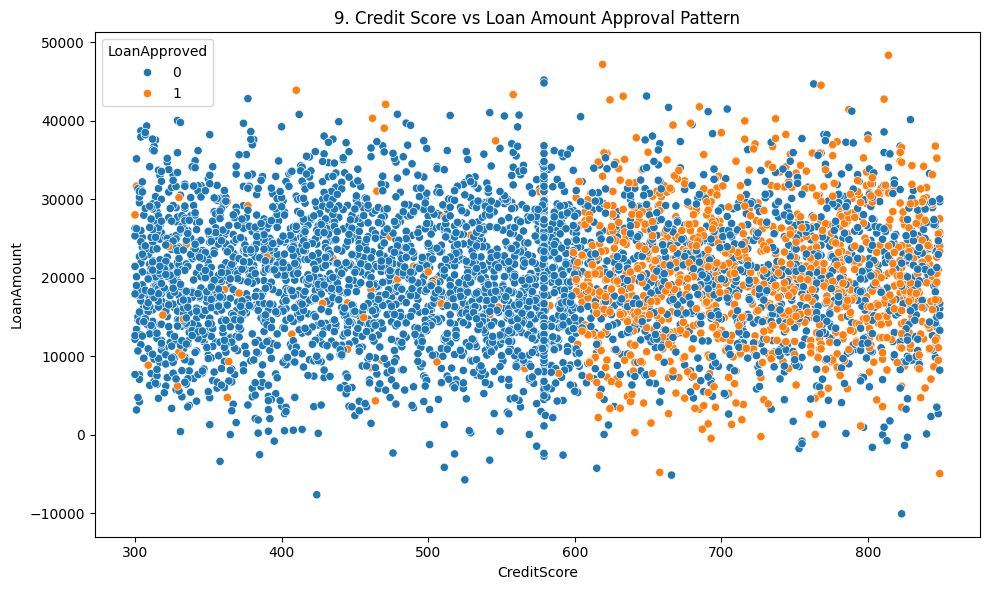

In [24]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='CreditScore', y='LoanAmount', hue='LoanApproved', data=df)
plt.title(f'{plot_no}. Credit Score vs Loan Amount Approval Pattern')
show_fig()
plot_no += 1

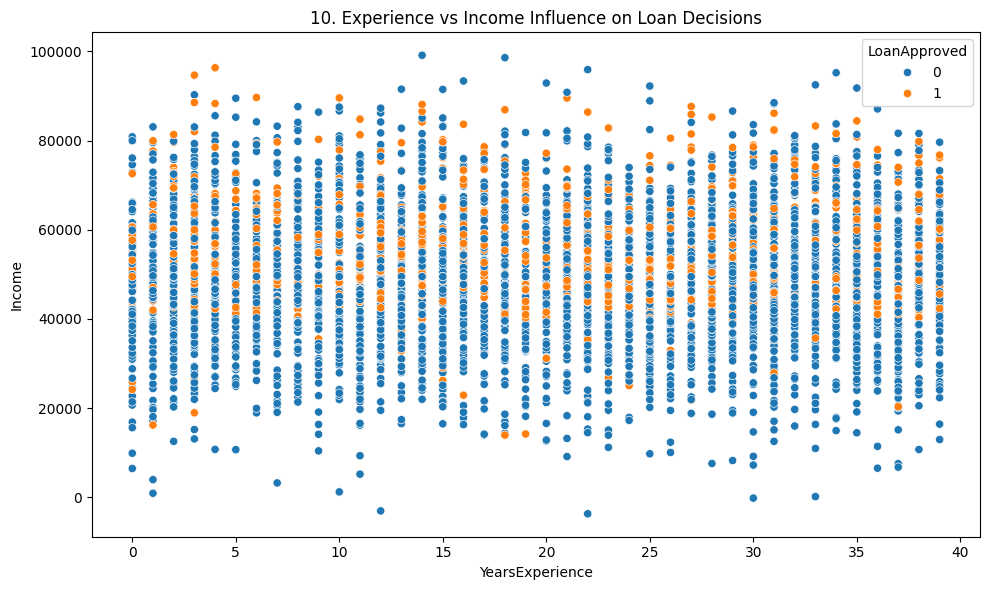

In [25]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='YearsExperience', y='Income', hue='LoanApproved', data=df)
plt.title(f'{plot_no}. Experience vs Income Influence on Loan Decisions')
show_fig()
plot_no += 1

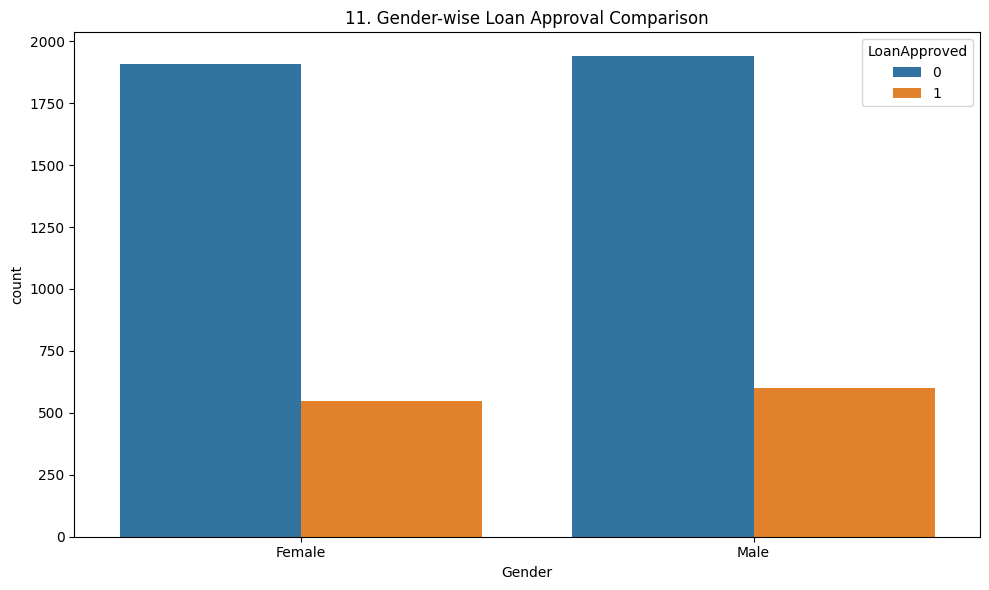

In [26]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='Gender', hue='LoanApproved', data=df)
plt.title(f'{plot_no}. Gender-wise Loan Approval Comparison')
show_fig()
plot_no += 1

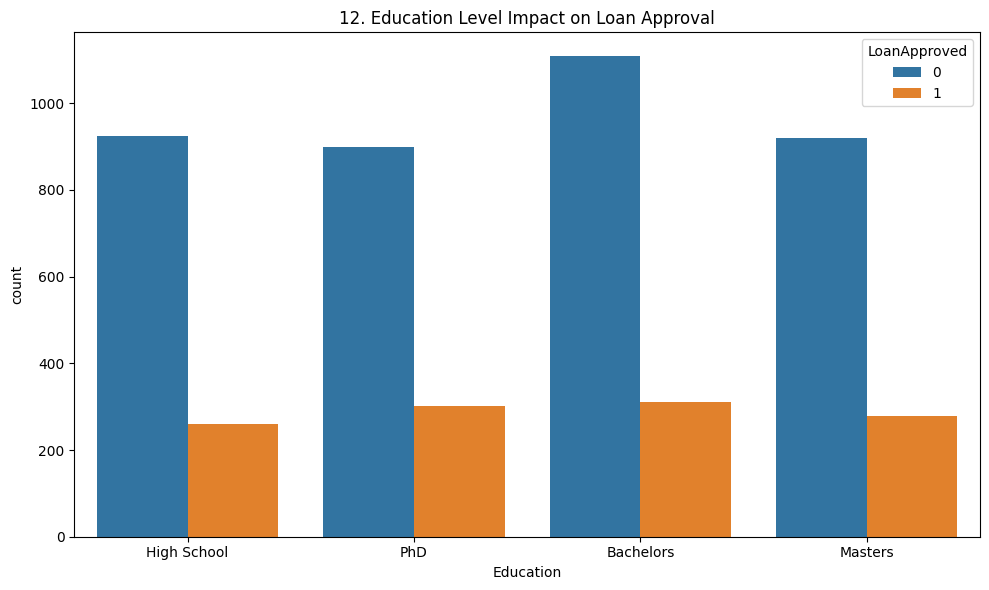

In [27]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='Education', hue='LoanApproved', data=df)
plt.title(f'{plot_no}. Education Level Impact on Loan Approval')
show_fig()
plot_no += 1

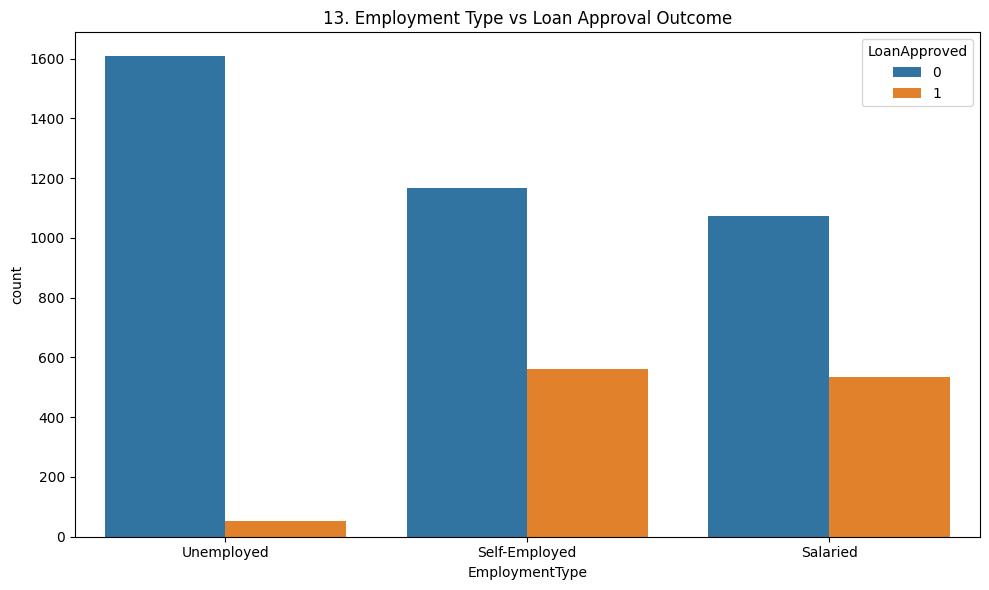

In [28]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='EmploymentType', hue='LoanApproved', data=df)
plt.title(f'{plot_no}. Employment Type vs Loan Approval Outcome')
show_fig()
plot_no += 1

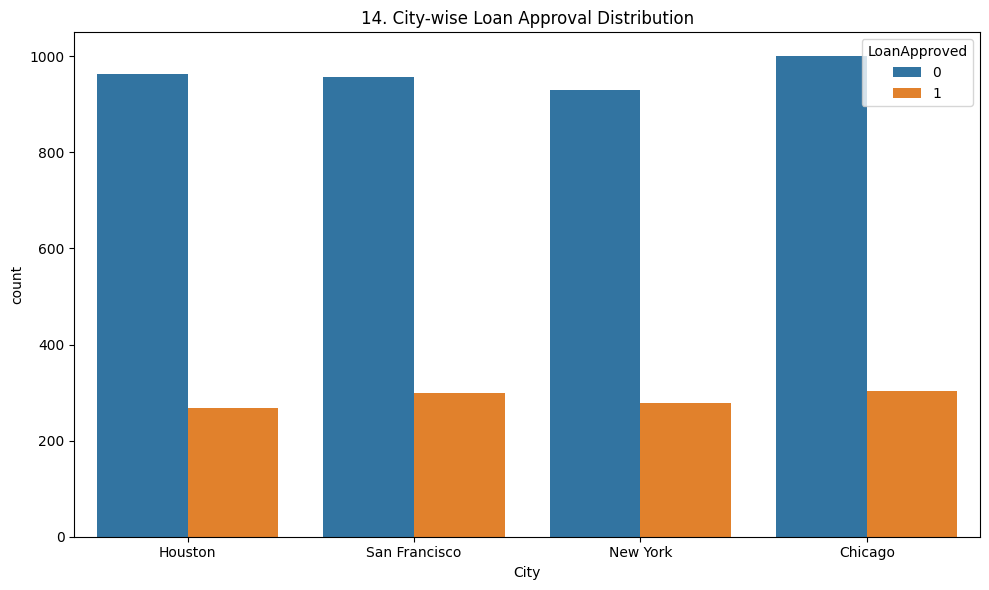

In [29]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='City', hue='LoanApproved', data=df)
plt.title(f'{plot_no}. City-wise Loan Approval Distribution')
show_fig()
plot_no += 1

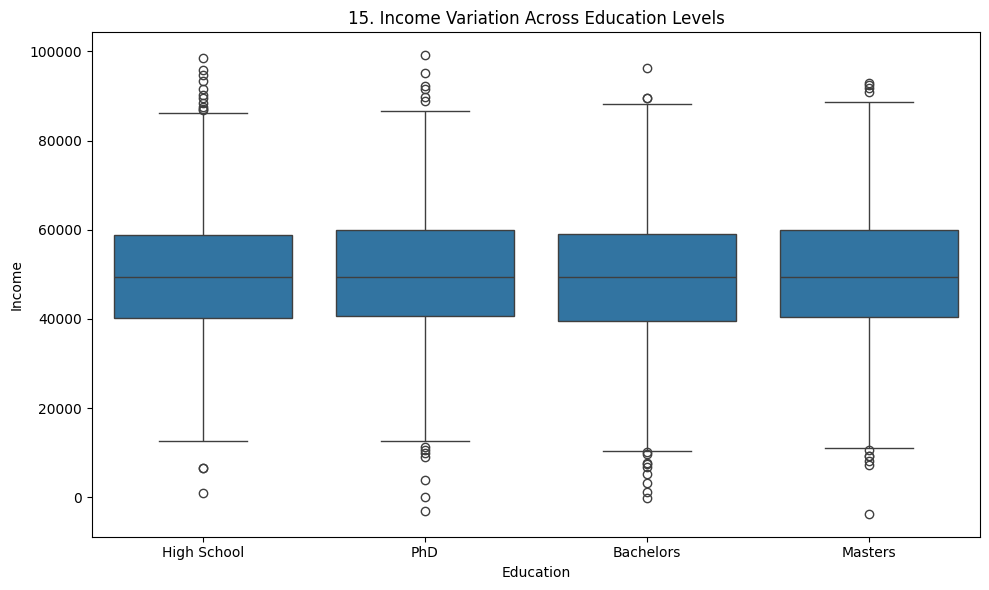

In [30]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='Education', y='Income', data=df)
plt.title(f'{plot_no}. Income Variation Across Education Levels')
show_fig()
plot_no += 1

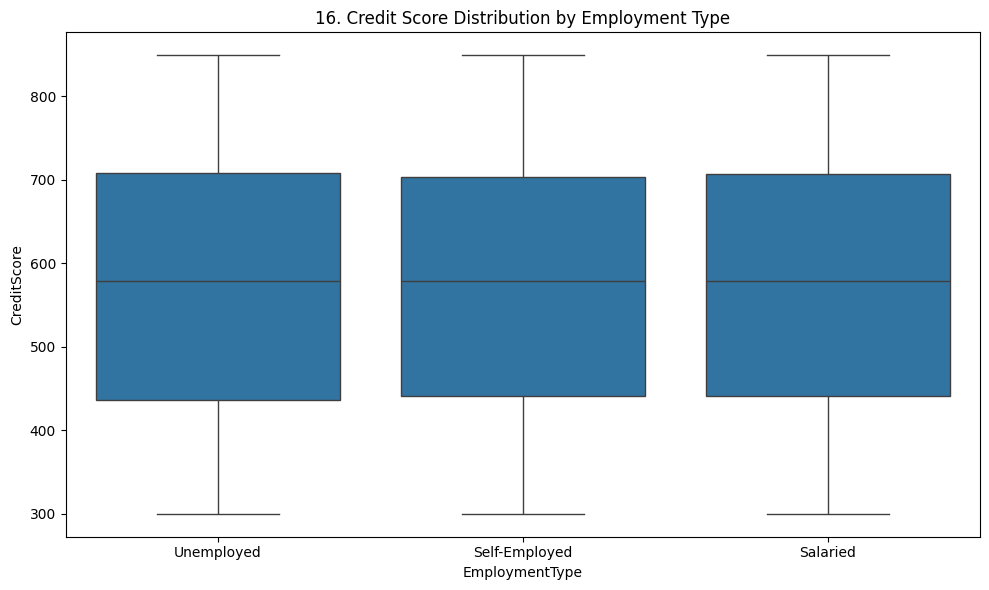

In [31]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='EmploymentType', y='CreditScore', data=df)
plt.title(f'{plot_no}. Credit Score Distribution by Employment Type')
show_fig()
plot_no += 1

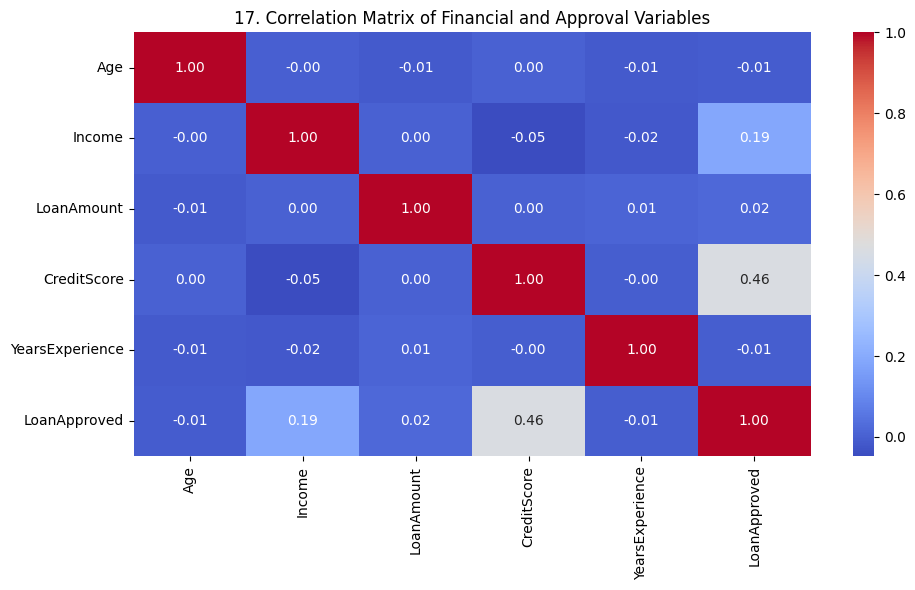

In [32]:
fig = plt.figure(figsize=(10,6))
corr = df[['Age','Income','LoanAmount','CreditScore','YearsExperience','LoanApproved']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title(f'{plot_no}. Correlation Matrix of Financial and Approval Variables')
show_fig()
plot_no += 1

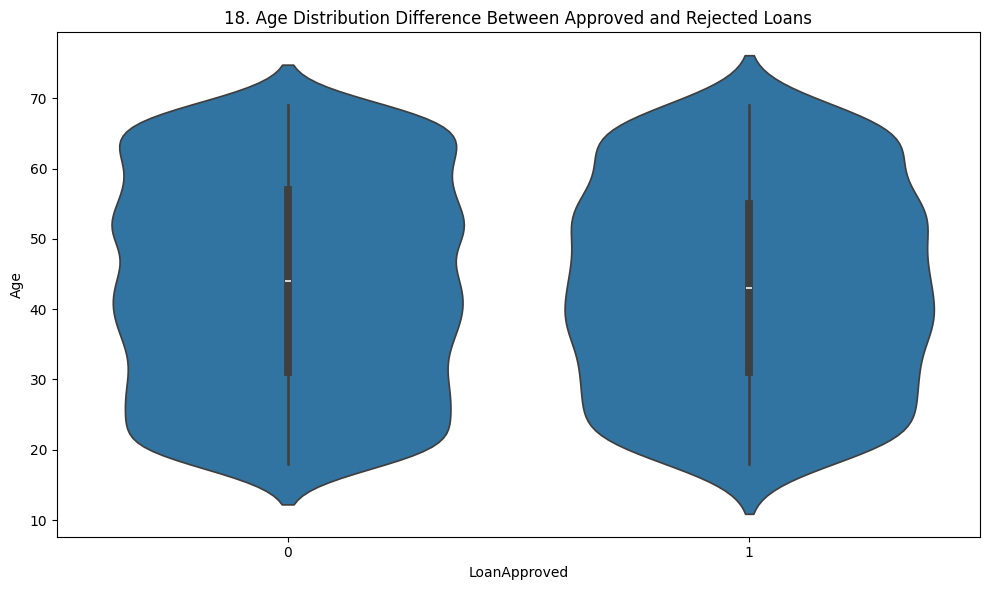

In [33]:
fig = plt.figure(figsize=(10,6))
sns.violinplot(x='LoanApproved', y='Age', data=df)
plt.title(f'{plot_no}. Age Distribution Difference Between Approved and Rejected Loans')
show_fig()
plot_no += 1

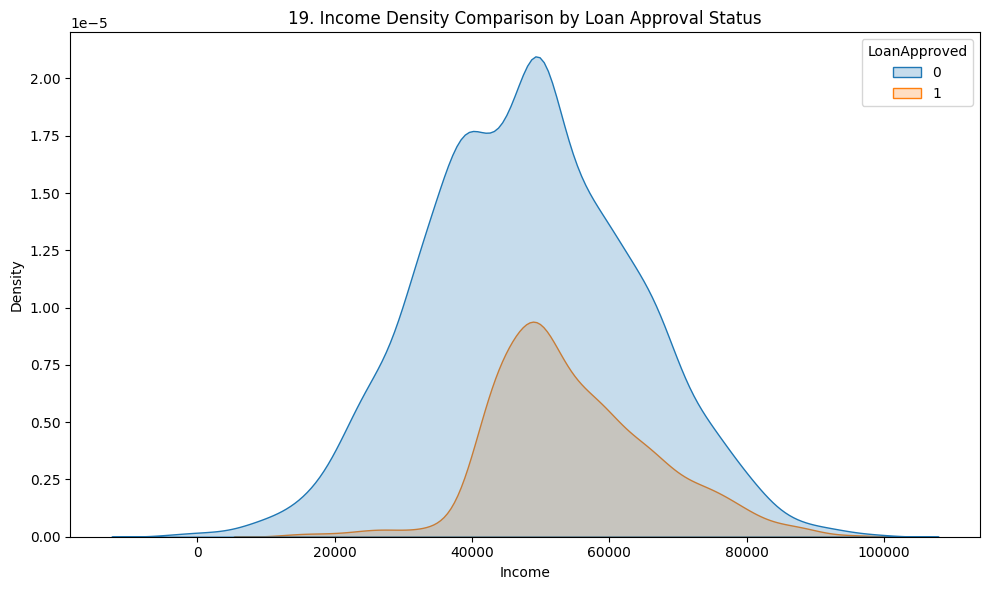

In [34]:
fig = plt.figure(figsize=(10,6))
sns.kdeplot(data=df, x='Income', hue='LoanApproved', fill=True)
plt.title(f'{plot_no}. Income Density Comparison by Loan Approval Status')
show_fig()
plot_no += 1

# Model Training

# Select features and target

In [35]:
X = df[['Age','Income','LoanAmount','CreditScore','YearsExperience']]
y = df['LoanApproved']

# Train-test split

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## Feature scaling

In [37]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Train Logistic Regression model

In [38]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

## Make predictions

In [39]:
y_pred = model.predict(X_test)

## Print accuracy score

In [40]:
print("Model Accuracy:", accuracy_score(y_test, y_pred))

Model Accuracy: 0.79


## Plot confusion matrix

<Figure size 600x500 with 0 Axes>

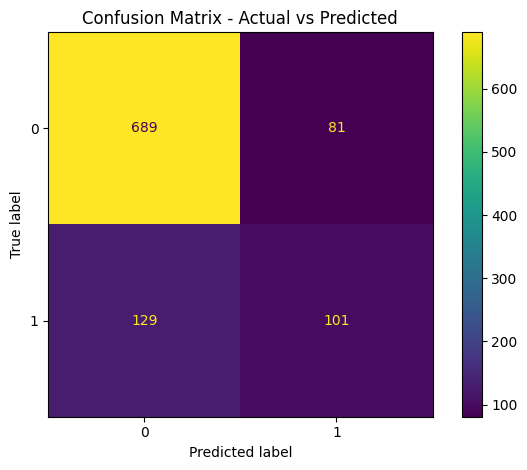

In [41]:
fig = plt.figure(figsize=(6,5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion Matrix - Actual vs Predicted")
plt.tight_layout()
plt.show()